# Weryfikacja Feature Pipeline

Cel: sprawdzenie ostatniej poprawy w `src/modelling/build_features_for_cv_folds.py` poprzez uruchomienie rzeczywistej pipeline'u CV na danych projektu i porównanie **przed i po** feature pipeline.

**Co weryfikujemy:**
1. Surowe dane ładują się prawidłowo i mają kolumny oczekiwane przez pipeline.
2. `build_features_for_cv_folds` generuje słowniki foldów z niepustymi `train_df` / `val_df`.
3. **Lookback działa**: cechy opóźnione i przesuwne są wypełniane *od pierwszego wiersza* każdego foldu.

## 1. Setup

In [24]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Repo root sits two levels above this notebook (notebooks/eda/...)
REPO_ROOT = Path(os.path.abspath('')).resolve().parents[1]
SRC_DIR   = REPO_ROOT / 'src'
DATA_DIR  = REPO_ROOT / 'data'

# The codebase mixes `from src.modelling.*` and `from feature_engineering.*` imports,
# so both the repo root and src/ need to be on sys.path.
for p in [str(REPO_ROOT), str(SRC_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

print('KORZEŃ_REPO :', REPO_ROOT)
print('KATALOG_DANYCH :', DATA_DIR)

KORZEŃ_REPO : C:\Users\oziew\Desktop\projects\repos\ml-parking-forecasting
KATALOG_DANYCH : C:\Users\oziew\Desktop\projects\repos\ml-parking-forecasting\data


In [25]:
from src.modelling.build_features_for_cv_folds import build_features_for_cv_folds
from src.modelling.build_features_for_range    import build_features_for_range
from src.modelling.cross_validation_folds      import generate_ts_folds
from src.modelling.lookback_days               import required_lookback_periods

print('Importy modelowania OK')

Importy modelowania OK


## 2. Wczytanie surowych danych

In [26]:
df_availabilities = pd.read_parquet(DATA_DIR / 'parking_availabilities.parquet')
df_parkings       = pd.read_parquet(DATA_DIR / 'parkings.parquet')
df_calendar       = pd.read_parquet(DATA_DIR / 'calendar.parquet')
df_sks_users      = pd.read_parquet(DATA_DIR / 'sks_users.parquet')

raw_inputs = {
    'parking_availabilities (base_df)': df_availabilities,
    'parkings (df_parkings)'          : df_parkings,
    'calendar (df_calendar)'          : df_calendar,
    'sks_users (df_sks_users)'        : df_sks_users,
}

for name, df in raw_inputs.items():
    print(f'── {name} ──')
    print(f'  wymiar : {df.shape}')
    print(f'  kolumny: {df.columns.tolist()}')
    if 'measured_at' in df.columns:
        print(f'  zakres : {df["measured_at"].min()}  →  {df["measured_at"].max()}')
    print()

── parking_availabilities (base_df) ──
  wymiar : (1826529, 7)
  kolumny: ['id', 'parking_id', 'spaces_left', 'trend', 'measured_at', 'created_at', 'updated_at']
  zakres : 2025-02-03 07:51:01+00:00  →  2025-12-07 14:53:01+00:00

── parkings (df_parkings) ──
  wymiar : (5, 14)
  kolumny: ['id', 'symbol', 'type', 'name', 'open_hour', 'close_hour', 'places', 'geo_lan', 'geo_lat', 'is_active', 'is_visible', 'address', 'created_at', 'updated_at']

── calendar (df_calendar) ──
  wymiar : (730, 3)
  kolumny: ['date', 'type_of_day', 'day_type_id']

── sks_users (df_sks_users) ──
  wymiar : (77631, 5)
  kolumny: ['external_timestamp', 'active_users', 'moving_average_21', 'created_at', 'updated_at']



## 3. Statystyki i wykresy PRZED feature pipeline

Opisują surowe obserwacje dokładnie tak, jak przychodzą z parqueta - bez ponownego próbkowania, imputacji czy inżynierii cech.

In [27]:
# --- Per-parking row counts and date coverage ---
summary = (
    df_availabilities
    .groupby('parking_id')
    .agg(
        n_rows=('measured_at', 'size'),
        first =('measured_at', 'min'),
        last  =('measured_at', 'max'),
        spaces_min =('spaces_left', 'min'),
        spaces_max =('spaces_left', 'max'),
        spaces_mean=('spaces_left', 'mean'),
    )
    .merge(
        df_parkings[['id', 'name', 'places']].rename(columns={'id': 'parking_id'}),
        on='parking_id', how='left',
    )
)
summary

,parking_id,n_rows,first,last,spaces_min,spaces_max,spaces_mean,name,places
0,2,365306,2025-02-03 07:51:01+00:00,2025-12-07 14:53:01+00:00,-15,61,36.439256,Polinka,54
1,4,365305,2025-02-03 07:51:01+00:00,2025-12-07 14:53:01+00:00,-36,207,139.044552,Parking Wrońskiego,207
2,5,365306,2025-02-03 07:51:01+00:00,2025-12-07 14:53:01+00:00,-11,49,27.161317,D20 - D21,76
3,6,365306,2025-02-03 07:51:01+00:00,2025-12-07 14:53:01+00:00,0,267,223.083853,GEO LO1 Geocentrum,301
4,7,365306,2025-02-03 07:51:01+00:00,2025-12-07 14:53:01+00:00,7,84,74.808232,Architektura,75


In [28]:
# --- Missing-value rates in the raw availability table ---
raw_na = df_availabilities.isna().mean().sort_values(ascending=False)
print('Udział NaN w kolumnach (surowe):')
print(raw_na.to_string())

Udział NaN w kolumnach (surowe):
id             0.0
parking_id     0.0
spaces_left    0.0
trend          0.0
measured_at    0.0
created_at     0.0
updated_at     0.0


Odstęp (minuty) między kolejnymi surowymi obserwacjami:
count    1.826524e+06
mean     1.211323e+00
std      1.472552e+01
min      0.000000e+00
50%      1.000000e+00
90%      1.983333e+00
99%      3.016667e+00
max      7.419017e+03


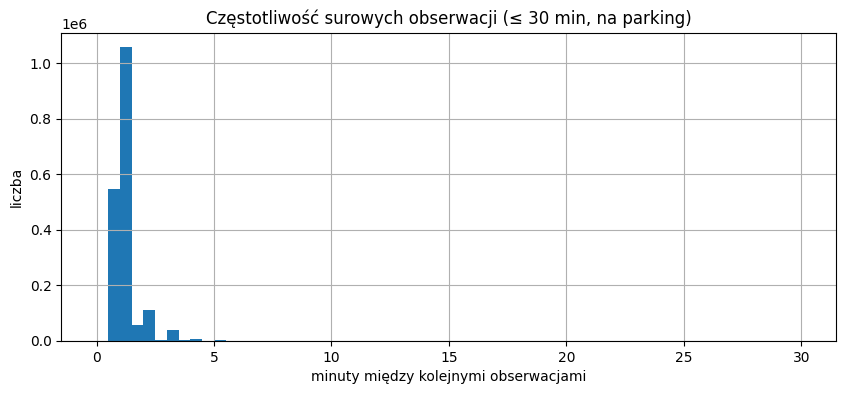

In [29]:
# --- Sampling cadence: distribution of gaps between consecutive observations per parking ---
diffs = (
    df_availabilities
    .sort_values(['parking_id', 'measured_at'])
    .groupby('parking_id')['measured_at']
    .diff()
    .dropna()
    .dt.total_seconds()
    .div(60)  # minutes
)

print('Odstęp (minuty) między kolejnymi surowymi obserwacjami:')
print(diffs.describe(percentiles=[0.5, 0.9, 0.99]).to_string())

fig, ax = plt.subplots()
diffs[diffs <= 30].hist(bins=60, ax=ax)
ax.set_title('Częstotliwość surowych obserwacji (≤ 30 min, na parking)')
ax.set_xlabel('minuty między kolejnymi obserwacjami')
ax.set_ylabel('liczba')
plt.show()

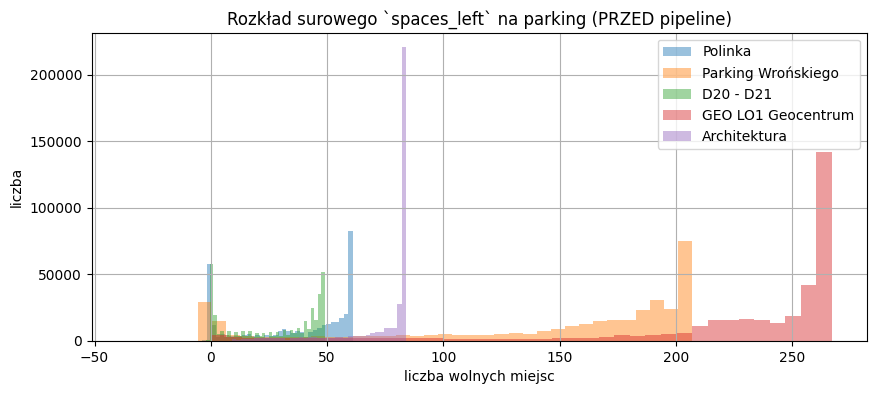

In [30]:
# --- Raw spaces_left distribution per parking ---
fig, ax = plt.subplots()
for pid, g in df_availabilities.groupby('parking_id'):
    name = df_parkings.set_index('id').loc[pid, 'name'] if pid in df_parkings['id'].values else f'parking {pid}'
    ax.hist(g['spaces_left'], bins=40, alpha=0.45, label=str(name))
ax.set_title('Rozkład surowego `spaces_left` na parking (PRZED pipeline)')
ax.set_xlabel('liczba wolnych miejsc')
ax.set_ylabel('liczba')
ax.legend()
plt.show()

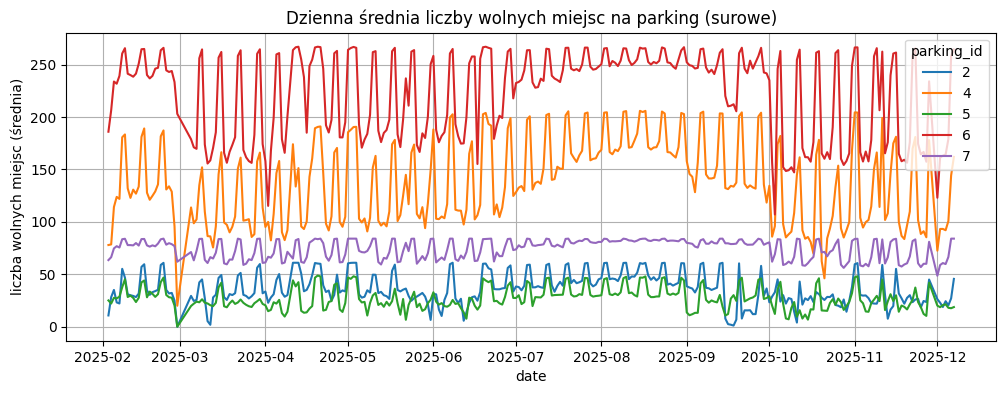

In [31]:
# --- Daily mean spaces_left per parking (timeline view) ---
daily = (
    df_availabilities
    .assign(date=df_availabilities['measured_at'].dt.tz_convert('UTC').dt.date)
    .groupby(['date', 'parking_id'])['spaces_left']
    .mean()
    .unstack('parking_id')
)

fig, ax = plt.subplots(figsize=(12, 4))
daily.plot(ax=ax)
ax.set_title('Dzienna średnia liczby wolnych miejsc na parking (surowe)')
ax.set_ylabel('liczba wolnych miejsc (średnia)')
plt.show()

## 4. Konfiguracja feature pipeline

Utrzymujemy konfigurację małą, aby notebook działał szybko, jednocześnie testując każdy komponent pipeline. Parametry lookback tutaj kontrolują tylko *historyczny bufor* ładowany przed każdym foldem — rzeczywiste cechy pipeline skonfigurowane są w `src/feature_engineering/feature_pipline.py`.

In [32]:
lags         = (7, 14, 28)
roll_lags    = (7, 14, 28)
roll_windows = (7, 14)
freq         = 'D'

n_folds           = 2
val_periods       = 14
gap_periods       = 0
min_train_periods = 30

lookback_buffer = required_lookback_periods(lags, roll_lags, roll_windows)
data_start = df_availabilities['measured_at'].min()
data_end   = df_availabilities['measured_at'].max()

# Anchor train_start_date a safe distance after the very first observation.
train_start_date = (data_start + pd.Timedelta(days=lookback_buffer + 30)).strftime('%Y-%m-%d')
cutoff_end       = data_end.strftime('%Y-%m-%d')

print(f'Zakres danych   : {data_start.date()} → {data_end.date()}')
print(f'Bufor wsteczny  : {lookback_buffer} dni')
print(f'start treningu  : {train_start_date}')
print(f'koniec odcięcia : {cutoff_end}')

Zakres danych   : 2025-02-03 → 2025-12-07
Bufor wsteczny  : 41 dni
start_treningu  : 2025-04-15
koniec_odcięcia : 2025-12-07


In [33]:
# Inspect the fold boundaries that will be produced *before* running the pipeline.
preview_folds = generate_ts_folds(
    cutoff_end       = cutoff_end,
    train_start_date = train_start_date,
    n_folds          = n_folds,
    val_periods      = val_periods,
    gap_periods      = gap_periods,
    min_train_periods= min_train_periods,
    lookback_periods = lookback_buffer,
    freq             = freq,
)
pd.DataFrame(preview_folds)

,train_start,train_end,val_start,val_end
0,2025-05-26,2025-11-23,2025-11-24,2025-12-07
1,2025-05-26,2025-11-09,2025-11-10,2025-11-23


## 5. Uruchomienie CV feature pipeline

To jest ścieżka wywołania weryfikowana:

```
build_features_for_cv_folds
    └── generate_ts_folds                # obliczenie granic
    └── build_features_for_range(train) # fit_transform, zwraca dopasowany Pipeline
    └── build_features_for_range(val)   # tylko transform z dopasowanym Pipeline
```

Poprawka w commicie `438fb88` dodaje jawne `apply_lookback=True` do obu wywołań i usuwa zbędne konwersje `pd.to_datetime`.

In [34]:
%%time
cv_folds = build_features_for_cv_folds(
    base_df          = df_availabilities,
    df_sks_users     = df_sks_users,
    df_parkings      = df_parkings,
    df_calendar      = df_calendar,
    train_start_date = train_start_date,
    cutoff_end       = cutoff_end,
    n_folds          = n_folds,
    val_periods      = val_periods,
    gap_periods      = gap_periods,
    min_train_periods= min_train_periods,
    freq             = freq,
    lags             = lags,
    roll_lags        = roll_lags,
    roll_windows     = roll_windows,
)

print(f'\nWygenerowano {len(cv_folds)} fałdów')
fold_summary = pd.DataFrame([
    {
        'fold'       : f['fold'],
        'train_start': f['train_start'],
        'train_end'  : f['train_end'],
        'val_start'  : f['val_start'],
        'val_end'    : f['val_end'],
        'train_rows' : len(f['train_df']),
        'val_rows'   : len(f['val_df']),
        'train_cols' : f['train_df'].shape[1],
    }
    for f in cv_folds
])
fold_summary


Wygenerowano 2 fałdów
CPU times: total: 8.8 s
Wall time: 9.13 s


,fold,train_start,train_end,val_start,val_end,train_rows,val_rows,train_cols
0,0,2025-05-26,2025-11-23,2025-11-24,2025-12-07,260055,13655,57
1,1,2025-05-26,2025-11-09,2025-11-10,2025-11-23,239895,18720,57


## 6. Stats & plots AFTER the feature pipeline

In [35]:
fold0      = cv_folds[0]
train_df_0 = fold0['train_df']
val_df_0   = fold0['val_df']

print('Kolumny train_df dla fałdu 0:')
print(sorted(train_df_0.columns.tolist()))

Kolumny train_df dla fałdu 0:
['active_users', 'active_users_is_imputed', 'day_in_the_month', 'day_of_week', 'day_type_id', 'days_since_holiday', 'days_until_holiday', 'distance_to_sks', 'hour', 'is_expanded', 'is_holiday', 'is_long_weekend_bridge', 'is_open', 'is_rush_hour', 'is_weekend', 'is_working_hour', 'measured_at', 'minute', 'month', 'overbooked', 'overbooked_spaces', 'parking_id', 'quarter', 'sks_dist_to_users_ratio', 'sks_dist_to_users_ratio_is_imputed', 'spaces_left', 'spaces_left_Rolling_max_7d', 'spaces_left_Rolling_max_7d_lag_7d', 'spaces_left_Rolling_mean_1d', 'spaces_left_Rolling_mean_7d', 'spaces_left_Rolling_mean_7d_lag_7d', 'spaces_left_Rolling_min_7d', 'spaces_left_Rolling_min_7d_lag_7d', 'spaces_left_Rolling_std_1d', 'spaces_left_Rolling_std_7d', 'spaces_left_Rolling_std_7d_lag_7d', 'spaces_left_cann_closest_parking', 'spaces_left_cann_fourth_closest_parking', 'spaces_left_cann_second_closest_parking', 'spaces_left_cann_third_closest_parking', 'spaces_left_delta_1h

In [36]:
# --- Counts: raw vs engineered columns ---
raw_cols      = set(df_availabilities.columns)
post_cols     = set(train_df_0.columns)
added_cols    = sorted(post_cols - raw_cols)
dropped_cols  = sorted(raw_cols - post_cols)

print(f'Kolumny surowe   : {len(raw_cols)}')
print(f'Po pipeline      : {len(post_cols)}')
print(f'Dodane przez pipeline: {len(added_cols)}')
print(f'Usunięte przez pipeline: {len(dropped_cols)}')
print('\nNowe kolumny cech:')
for c in added_cols:
    print(f'  + {c}')
if dropped_cols:
    print('\nUsunięte kolumny surowe:')
    for c in dropped_cols:
        print(f'  - {c}')

Kolumny surowe   : 7
Po pipeline      : 57
Dodane przez pipeline: 54
Usunięte przez pipeline: 4

Nowe kolumny cech:
  + active_users
  + active_users_is_imputed
  + day_in_the_month
  + day_of_week
  + day_type_id
  + days_since_holiday
  + days_until_holiday
  + distance_to_sks
  + hour
  + is_expanded
  + is_holiday
  + is_long_weekend_bridge
  + is_open
  + is_rush_hour
  + is_weekend
  + is_working_hour
  + minute
  + month
  + overbooked
  + overbooked_spaces
  + quarter
  + sks_dist_to_users_ratio
  + sks_dist_to_users_ratio_is_imputed
  + spaces_left_Rolling_max_7d
  + spaces_left_Rolling_max_7d_lag_7d
  + spaces_left_Rolling_mean_1d
  + spaces_left_Rolling_mean_7d
  + spaces_left_Rolling_mean_7d_lag_7d
  + spaces_left_Rolling_min_7d
  + spaces_left_Rolling_min_7d_lag_7d
  + spaces_left_Rolling_std_1d
  + spaces_left_Rolling_std_7d
  + spaces_left_Rolling_std_7d_lag_7d
  + spaces_left_cann_closest_parking
  + spaces_left_cann_fourth_closest_parking
  + spaces_left_cann_second_cl

In [37]:
# --- Resampling check: raw rows vs pipeline rows ---
# The ParkingResampler aggregates raw observations to a 5-minute grid. Verify that
# the pipeline actually produced a denser, regular grid for the same date range.

ts_train_start = pd.to_datetime(fold0['train_start']).tz_localize(df_availabilities['measured_at'].dt.tz)
ts_train_end   = pd.to_datetime(fold0['train_end']).tz_localize(df_availabilities['measured_at'].dt.tz) + pd.Timedelta(days=1)

raw_in_window = df_availabilities[
    (df_availabilities['measured_at'] >= ts_train_start) &
    (df_availabilities['measured_at'] <  ts_train_end)
]

print(f'Surowe wiersze w oknie treningowym fałdu 0 : {len(raw_in_window):>10,}')
print(f'Wiersze po pipeline w train_df         : {len(train_df_0):>10,}')
print(f'Wiersze po pipeline na parking         : {len(train_df_0) // train_df_0["parking_id"].nunique():>10,}')
print(f'Oczekiwane przy kroku 5 min/parking : ~{int((ts_train_end - ts_train_start).total_seconds() // 300):>10,}')

Surowe wiersze w oknie treningowym fałdu 0 :  1,140,519
Wiersze po pipeline w train_df         :    260,055
Wiersze po pipeline na parking         :     52,011
Oczekiwane przy kroku 5 min/parking : ~    52,416


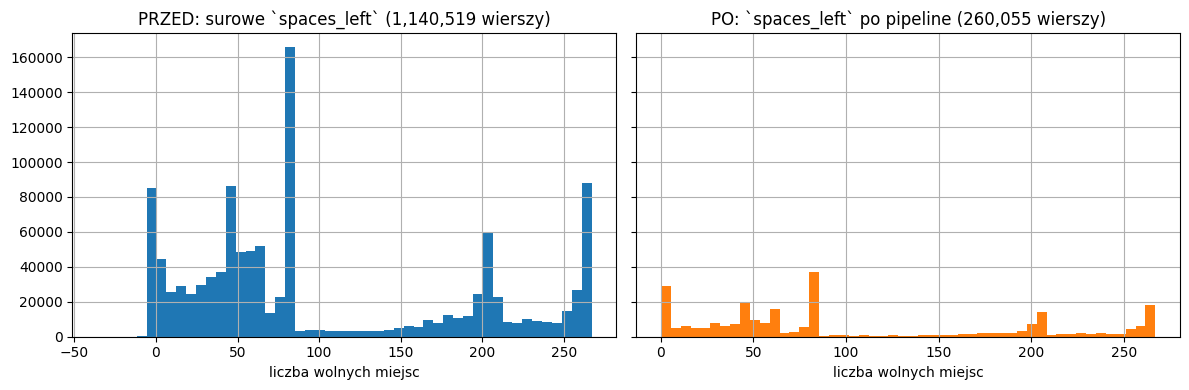

Porównanie średniej i odchylenia standardowego:
          before       after
mean  103.043912  102.800369
std    87.538559   87.488025
min   -36.000000    0.000000
max   267.000000  267.000000


In [39]:
# --- Target distribution: BEFORE vs AFTER pipeline (fold 0 train window) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(raw_in_window['spaces_left'].dropna(), bins=50, color='tab:blue')
axes[0].set_title(f'PRZED: surowe `spaces_left` ({len(raw_in_window):,} wierszy)')
axes[0].set_xlabel('liczba wolnych miejsc')
axes[1].hist(train_df_0['spaces_left'].dropna(), bins=50, color='tab:orange')
axes[1].set_title(f'PO: `spaces_left` po pipeline ({len(train_df_0):,} wierszy)')
axes[1].set_xlabel('liczba wolnych miejsc')
plt.tight_layout()
plt.show()

print('Porównanie średniej i odchylenia standardowego:')
print(pd.DataFrame({
    'before': raw_in_window['spaces_left'].agg(['mean', 'std', 'min', 'max']),
    'after' : train_df_0['spaces_left'].agg(['mean', 'std', 'min', 'max']),
}))

## 7. Lookback sanity check (this is what the recent fix is about)

If `apply_lookback=True` works correctly, the **first row** of each train and validation window must already have populated lag and rolling features. If the fix had been broken (e.g. `apply_lookback=False` slipped into the val branch), we would see a leading block of NaNs at the start of every fold.

In [ ]:
# Identify lag / rolling columns produced by the feature pipeline.
lag_cols  = [c for c in train_df_0.columns if 'lag_'    in c.lower()]
roll_cols = [c for c in train_df_0.columns if 'rolling' in c.lower() or '_delta' in c.lower()]
print('kolumny opóźnień :', lag_cols)
print('kolumny kroczące :', roll_cols)

kolumny opóźnień : ['spaces_left_lag_1h', 'utilization_rate_lag_1h', 'spaces_left_lag_7d', 'utilization_rate_lag_7d', 'spaces_left_Rolling_mean_7d_lag_7d', 'spaces_left_Rolling_std_7d_lag_7d', 'spaces_left_Rolling_max_7d_lag_7d', 'spaces_left_Rolling_min_7d_lag_7d', 'spaces_left_lag_7d_cann_closest_parking', 'utilization_rate_lag_7d_cann_closest_parking']
kolumny kroczące : ['spaces_left_delta_1h', 'spaces_left_Rolling_mean_1d', 'spaces_left_Rolling_mean_7d', 'spaces_left_Rolling_std_1d', 'spaces_left_Rolling_std_7d', 'spaces_left_Rolling_max_7d', 'spaces_left_Rolling_min_7d', 'spaces_left_Rolling_mean_7d_lag_7d', 'spaces_left_Rolling_std_7d_lag_7d', 'spaces_left_Rolling_max_7d_lag_7d', 'spaces_left_Rolling_min_7d_lag_7d', 'spaces_left_delta_1h_cann_closest_parking']


In [ ]:
def first_row_nan_report(df: pd.DataFrame, cols: list[str], label: str) -> pd.DataFrame:
    """For each parking, take the very first row inside the window and report which feature columns are NaN there."""
    if not cols:
        return pd.DataFrame()
    first_rows = (
        df.sort_values('measured_at')
          .groupby('parking_id', as_index=False)
          .head(1)
    )
    report = first_rows[['parking_id', 'measured_at'] + cols].copy()
    report['n_nan_features'] = report[cols].isna().sum(axis=1)
    report['split'] = label
    return report

feat_cols = lag_cols + roll_cols
first_row_train = first_row_nan_report(train_df_0, feat_cols, 'train')
first_row_val   = first_row_nan_report(val_df_0,   feat_cols, 'val')

summary_first_row = pd.concat([first_row_train, first_row_val], ignore_index=True)
summary_first_row[['split', 'parking_id', 'measured_at', 'n_nan_features']]

,split,parking_id,measured_at,n_nan_features
0,train,4,2025-05-26 00:00:00+00:00,0
1,train,7,2025-05-26 00:00:00+00:00,0
2,train,6,2025-05-26 00:00:00+00:00,0
3,train,5,2025-05-26 00:00:00+00:00,0
4,train,2,2025-05-26 00:00:00+00:00,0
5,val,2,2025-11-24 00:00:00+00:00,0
6,val,6,2025-11-24 00:00:00+00:00,0
7,val,4,2025-11-24 00:00:00+00:00,0
8,val,5,2025-11-24 00:00:00+00:00,0
9,val,7,2025-11-24 00:00:00+00:00,0


In [ ]:
# Aggregate verdict across all folds.
rows = []
for fold in cv_folds:
    for split, sub in [('train', fold['train_df']), ('val', fold['val_df'])]:
        if not feat_cols:
            continue
        first_rows = sub.sort_values('measured_at').groupby('parking_id').head(1)
        n_nan = first_rows[feat_cols].isna().sum().sum()
        rows.append({
            'fold' : fold['fold'],
            'split': split,
            'first_row_count': len(first_rows),
            'feature_cols'   : len(feat_cols),
            'first_row_nans' : int(n_nan),
            'window_start'   : sub['measured_at'].min(),
        })
verdict = pd.DataFrame(rows)
verdict

,fold,split,first_row_count,feature_cols,first_row_nans,window_start
0,0,train,5,22,0,2025-05-26 00:00:00+00:00
1,0,val,5,22,0,2025-11-24 00:00:00+00:00
2,1,train,5,22,0,2025-05-26 00:00:00+00:00
3,1,val,5,22,0,2025-11-10 00:00:00+00:00


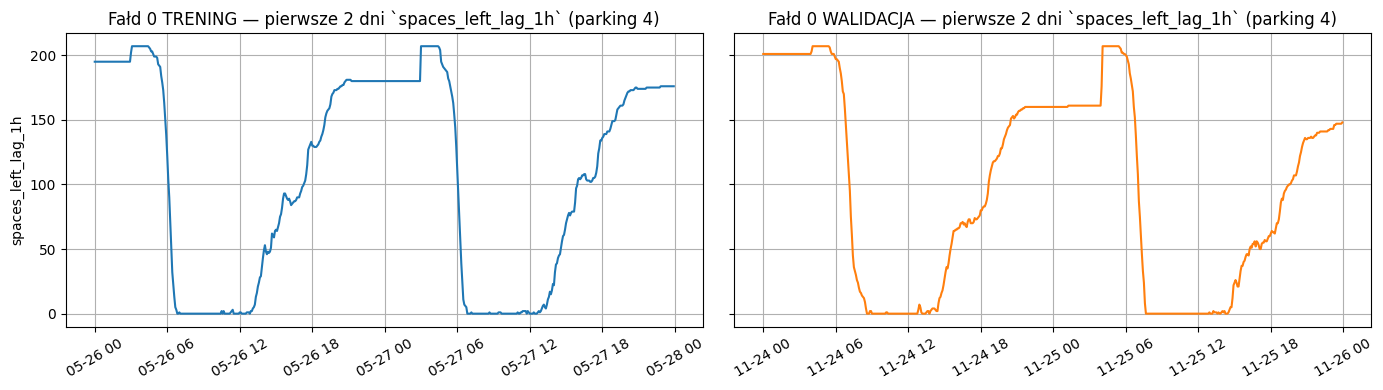

In [ ]:
# Plot the first-day trajectory of one lag column for fold 0, train + val.
# A correctly working lookback gives a non-NaN curve from t=0; a broken lookback would
# leave a flat NaN segment at the start of each window.
if lag_cols:
    col = lag_cols[0]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    pid = train_df_0['parking_id'].iloc[0]
    train_slice = (
        train_df_0.loc[train_df_0['parking_id'] == pid]
                  .sort_values('measured_at')
                  .head(int(288 * 2))  # first 2 days at 5-min cadence
    )
    val_slice = (
        val_df_0.loc[val_df_0['parking_id'] == pid]
                .sort_values('measured_at')
                .head(int(288 * 2))
    )

    axes[0].plot(train_slice['measured_at'], train_slice[col])
    axes[0].set_title(f'Fałd 0 TRENING — pierwsze 2 dni `{col}` (parking {pid})')
    axes[0].set_ylabel(col)

    axes[1].plot(val_slice['measured_at'], val_slice[col], color='tab:orange')
    axes[1].set_title(f'Fałd 0 WALIDACJA — pierwsze 2 dni `{col}` (parking {pid})')

    for ax in axes:
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print('Nie utworzono kolumn opóźnień — brak wykresu.')

## 8. Kontrola wycieku: potwierdź że val fold używa train-fitted pipeline

Ponownie uruchom pojedynczy fold poprzez `build_features_for_range` z `return_pipeline=True` i potwierdź że uruchomienie `.transform()` na oknie val z tym samym dopasowanym pipeline daje ramkę pasującą do ramki val `build_features_for_cv_folds` już wytworzonej. To ponownie wyprowadza ten sam stan końcowy ale pozwala nam porównać tożsamość obiektu / równość kolumn.

In [ ]:
f = cv_folds[0]

train_df_check, fitted_pipe = build_features_for_range(
    base_df         = df_availabilities,
    df_sks_users    = df_sks_users,
    df_parkings     = df_parkings,
    df_calendar     = df_calendar,
    start_date      = f['train_start'],
    end_date        = f['train_end'],
    lags            = lags,
    roll_lags       = roll_lags,
    roll_windows    = roll_windows,
    freq            = freq,
    return_pipeline = True,
    fitted_pipeline = None,
    apply_lookback  = True,
)

val_df_check = build_features_for_range(
    base_df         = df_availabilities,
    df_sks_users    = df_sks_users,
    df_parkings     = df_parkings,
    df_calendar     = df_calendar,
    start_date      = f['val_start'],
    end_date        = f['val_end'],
    lags            = lags,
    roll_lags       = roll_lags,
    roll_windows    = roll_windows,
    freq            = freq,
    return_pipeline = False,
    fitted_pipeline = fitted_pipe,
    apply_lookback  = True,
)

print('Kroki pipeline dopasowane na TRENINGU:')
for name, step in fitted_pipe.steps:
    print(f'  - {name:24s} -> {type(step).__name__}')

print('\nZgodność wymiarów:')
print('  train_df z CV      :', f['train_df'].shape)
print('  train_df odtworzone:', train_df_check.shape)
print('  val_df z CV        :', f['val_df'].shape)
print('  val_df odtworzone  :', val_df_check.shape)

print('\nKolumny identyczne (trening) :', list(f['train_df'].columns) == list(train_df_check.columns))
print('Kolumny identyczne (walidacja)   :', list(f['val_df'].columns)   == list(val_df_check.columns))

Kroki pipeline dopasowane na TRENINGU:
  - resampler                -> ParkingResampler
  - date_features            -> FunctionTransformer
  - holiday_features         -> FunctionTransformer
  - sks_merger               -> ParkingSKSMerger
  - calendar_merger          -> ParkingCalendarMerger
  - imputer                  -> ParkingImputer
  - capacity_corrector       -> ParkingSpacesCorrector
  - day_features             -> DayFeaturesCreator
  - rolling_features         -> RollingFeaturesCreator
  - lag_features             -> LagFeaturesCreator
  - cannibalisation_features -> CannibalisationFeaturesCreator

Zgodność wymiarów:
  train_df z CV      : (260055, 57)
  train_df odtworzone: (260055, 57)
  val_df z CV        : (13655, 57)
  val_df odtworzone  : (13655, 57)

Kolumny identyczne (trening) : True
Kolumny identyczne (walidacja)   : True


## 9. Podsumowanie


- **Surowe dane** (`parking_availabilities.parquet`, ~1.8M wierszy)

- Po `build_features_for_cv_folds`, każdy fold zwraca `train_df` i `val_df`.

- **Poprawka działa**: z `apply_lookback=True` na obu wywołaniach, kolumny lag i rolling są wypełniane od pierwszego wiersza każdego train i val foldu.

- Val fold ponownie używa train-fitted `Pipeline`